In [5059]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

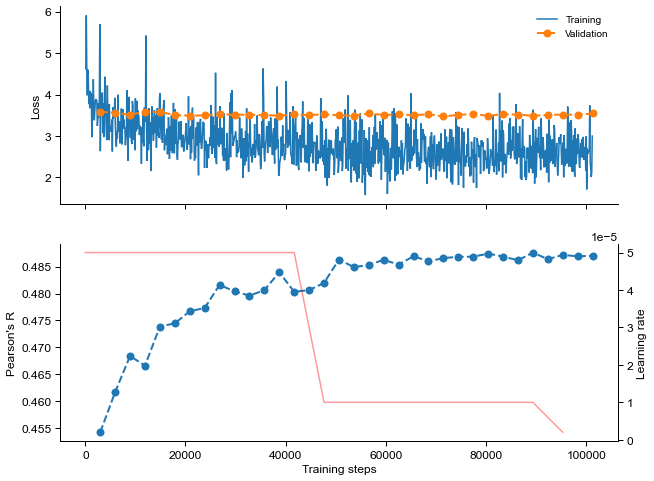

In [6835]:
metrics = pd.read_csv(
    "models/variant_data_AUG3_with_warmup_and_decay_var_split_v3/logs/lightning_logs/version_0/metrics.csv"
)

i = metrics.loss.abs() > 100
metrics.loc[i, "loss"] = pd.NA


val_steps = ~metrics.val_loss.isna()
val_metrics = metrics[val_steps]
train_metrics = metrics[~val_steps]

fig, ax = plt.subplots(2, 1, sharex=True)


i = ~np.isnan(metrics.loss)
ax[0].plot(metrics.step[i], metrics.loss[i], label="Training")
ax[0].plot(
    val_metrics.step, val_metrics.val_loss, "o--", lw=2, ms=8, label="Validation"
)

ax[0].set_ylabel("Loss")
ax[0].legend()

# ax[0].set_ylim(10, 40)

ax[1].plot(val_metrics.step, val_metrics.val_pcc, "o--", lw=2, ms=8, label="Correlation")
ax[1].set_xlabel("Training steps")
ax[1].set_ylabel("Pearson's R")


i = ~np.isnan(metrics["lr-AdamW"])

tax = ax[1].twinx()
tax.plot(metrics.step[i], metrics["lr-AdamW"][i], color="red", alpha=0.4, label="Learning rate")
tax.set_ylabel("Learning rate")
         
ax[1].spines["right"].set_visible(True)


fig.set_size_inches(10, 8)

In [6833]:
val_metrics.sort_values(by="step")

,epoch,loss,lr-AdamW,step,val_loss,val_pcc
30,0.0,NaN,NaN,2977,3.581063,0.454158
61,0.0,NaN,NaN,5955,3.563714,0.461638
93,1.0,NaN,NaN,8934,3.507692,0.468362
124,1.0,NaN,NaN,11912,3.588561,0.466561
155,2.0,NaN,NaN,14891,3.576358,0.473854
186,2.0,NaN,NaN,17869,3.508075,0.474440
218,3.0,NaN,NaN,20848,3.491589,0.476695
249,3.0,NaN,NaN,23826,3.497087,0.477308
281,4.0,NaN,NaN,26805,3.520752,0.481611
311,4.0,NaN,NaN,29783,3.513618,0.480382


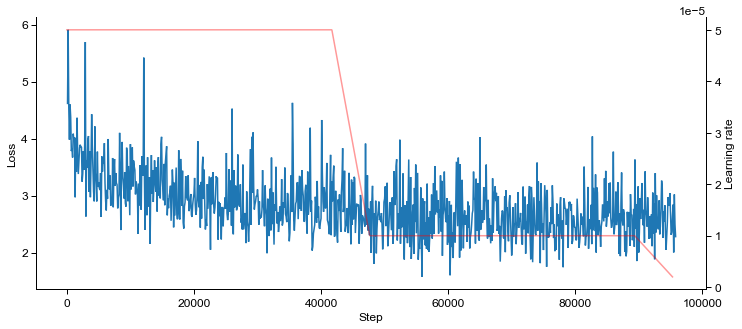

In [6834]:
fig, ax = plt.subplots()

i = ~np.isnan(metrics.loss)
ax.plot(metrics.step[i], metrics.loss[i])
ax.set_xlabel("Step")
ax.set_ylabel("Loss")

# ax.set_ylim(10, 40)
#
ax = ax.twinx()
i = ~np.isnan(metrics["lr-AdamW"])
ax.plot(metrics.step[i], metrics["lr-AdamW"][i], color="red", alpha=0.4)

ax.set_ylabel("Learning rate")

ax.spines["right"].set_visible(True)


fig.set_size_inches(12, 5)

In [6815]:
metrics

,epoch,loss,lr-AdamW,step,val_loss,val_pcc
0,NaN,NaN,0.00005,0,NaN,NaN
1,0.0,4.617582,NaN,99,NaN,NaN
2,0.0,5.908704,NaN,199,NaN,NaN
3,0.0,4.553437,NaN,299,NaN,NaN
4,0.0,3.981385,NaN,399,NaN,NaN
...,...,...,...,...,...,...
651,10.0,2.535385,NaN,62099,NaN,NaN
652,10.0,3.277271,NaN,62199,NaN,NaN
653,10.0,2.701030,NaN,62299,NaN,NaN
654,10.0,2.076961,NaN,62399,NaN,NaN
